# Cap Impedance Analysis

Converted from: *Cap Impedance converted from numbers.xlsx*

**Contents:**
1. RC Circuit Impedance
2. Op-Amp Output Voltage (Vo and Rf)
3. Waveform Vx(t)
4. CNT Supercapacitor Design
5. COVID DNA Biosensor — CEDL Model
6. COVID DNA Biosensor — Full Model
7. Detection Curve

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

---
## 1. RC Circuit Impedance
*(Sheet 1)*

Computes capacitive reactance $X_C = \frac{1}{2\pi f C}$, impedance $Z = \sqrt{R^2 + X_C^2}$, and output voltage for an RC circuit.

In [2]:
# ── Parameters ─────────────────────────────────────────────────────────────────
pi   = 22 / 7
f    = 0.25      # Frequency (Hz)
C    = 9.6e-5    # Capacitance (F)  [96 µF]
R    = 98        # Resistance (Ω)
V    = 1         # Input voltage (V)

# Op-amp / output parameters
V_fix  = 1.65    # Fixed bias voltage (V)
V_in   = 0.3     # Input signal voltage (V)
Rf     = 10000   # Feedback resistor (Ω)
V_min_sig = -0.3 # Minimum signal voltage (V)

# ── Calculations ───────────────────────────────────────────────────────────────
T            = 1 / f                        # Period (s)
two_pi_f_C   = 2 * pi * f * C              # 2πfC
Xc           = 1 / two_pi_f_C              # Capacitive reactance (Ω)
Z            = np.sqrt(R**2 + Xc**2)       # Impedance (Ω)
i_current    = V / Z                        # Current (A)

V_work       = V_fix + V_in                # Working voltage (V)  [1.65 + 0.3]
V_out        = (i_current * Rf) + V_work   # Output voltage (V)

V_max_sig    = V_in                         # Signal max (V)
amplitude    = (abs(V_max_sig) + abs(V_min_sig)) / 2  # Amplitude (V)

# ── Print results ──────────────────────────────────────────────────────────────
print("RC Circuit Impedance")
print("=" * 40)
print(f"  Frequency         f  = {f} Hz")
print(f"  Capacitance       C  = {C*1e6:.1f} µF")
print(f"  Resistance        R  = {R} Ω")
print(f"  Period            T  = {T} s")
print(f"  Capacitive React. Xc = {Xc:.4f} Ω")
print(f"  Impedance         Z  = {Z:.4f} Ω")
print(f"  Current           i  = {i_current:.6f} A")
print()
print(f"  V_fix             = {V_fix} V")
print(f"  V_in              = {V_in} V")
print(f"  V_work            = {V_work} V")
print(f"  Feedback Rf       = {Rf} Ω")
print(f"  V_out             = {V_out:.4f} V")
print(f"  Amplitude         = {amplitude} V")

RC Circuit Impedance
  Frequency         f  = 0.25 Hz
  Capacitance       C  = 96.0 µF
  Resistance        R  = 98 Ω
  Period            T  = 4.0 s
  Capacitive React. Xc = 6628.7879 Ω
  Impedance         Z  = 6629.5123 Ω
  Current           i  = 0.000151 A

  V_fix             = 1.65 V
  V_in              = 0.3 V
  V_work            = 1.95 V
  Feedback Rf       = 10000 Ω
  V_out             = 3.4584 V
  Amplitude         = 0.3 V


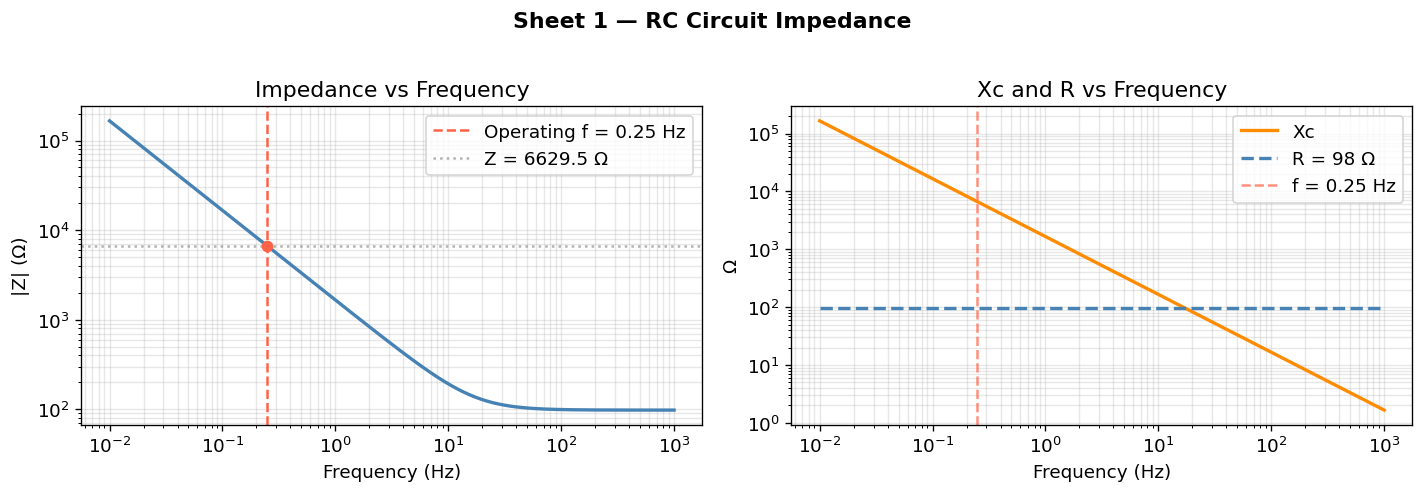

In [3]:
# Plot |Z| vs Frequency
f_range = np.logspace(-2, 3, 500)          # 0.01 Hz → 1000 Hz
Xc_range = 1 / (2 * pi * f_range * C)
Z_range  = np.sqrt(R**2 + Xc_range**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# |Z| vs frequency
axes[0].loglog(f_range, Z_range, 'steelblue', linewidth=2)
axes[0].axvline(f, color='tomato', linestyle='--', label=f'Operating f = {f} Hz')
axes[0].axhline(Z, color='gray', linestyle=':', alpha=0.6, label=f'Z = {Z:.1f} Ω')
axes[0].scatter([f], [Z], color='tomato', zorder=5)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('|Z| (Ω)')
axes[0].set_title('Impedance vs Frequency')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

# Xc vs frequency
axes[1].loglog(f_range, Xc_range, 'darkorange', linewidth=2, label='Xc')
axes[1].loglog(f_range, np.full_like(f_range, R), 'steelblue', linewidth=2,
               linestyle='--', label=f'R = {R} Ω')
axes[1].axvline(f, color='tomato', linestyle='--', alpha=0.7,
                label=f'f = {f} Hz')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Ω')
axes[1].set_title('Xc and R vs Frequency')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('Sheet 1 — RC Circuit Impedance', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Op-Amp Output Voltage (Vo and Rf)
*(Value of Vo and Rf sheet)*

Models an inverting op-amp driven by a **triangular wave** input. Computes output voltage $V_o = i \cdot R_f + V_{work}$, current $i = V_{peak}/Z$, and phase angle.

In [4]:
# ── Parameters ─────────────────────────────────────────────────────────────────
Rf_op    = 1000      # Feedback resistance (Ω)
Vmax_op  = 1.0       # Max input voltage (V)
Vmin_op  = -1.0      # Min input voltage (V)
R_op     = 100       # Series resistance (Ω)
C_op     = 1e-4      # Capacitance (F)  [100 µF]
f_op     = 0.25      # Frequency (Hz)
V_ref    = 1.65      # Reference / bias voltage (V)

# ── Derived quantities ─────────────────────────────────────────────────────────
V_peak   = (Vmax_op - Vmin_op) / 2        # Peak voltage (V)
V_pp     = Vmax_op - Vmin_op              # Peak-to-peak (V)
T_op     = 1 / f_op                       # Period (s)
Xc_op    = 1 / (2 * pi * f_op * C_op)    # Capacitive reactance (Ω)
Z_op     = np.sqrt(R_op**2 + Xc_op**2)   # Impedance (Ω)
V_per_s  = 4 * f_op * V_peak             # Slew rate (V/s)
i_op     = V_peak / Z_op                  # Current (A)
phase_rad = np.arctan(Xc_op / R_op)       # Phase angle (rad)
phase_deg = np.degrees(phase_rad)          # Phase angle (°)

# ── Waveform functions ─────────────────────────────────────────────────────────
def triangular_wave(t, f, Vpeak, Vref):
    """Triangular wave centred at Vref."""
    T = 1 / f
    t_mod = t % T
    # Rising half: 0 → T/2,  Falling half: T/2 → T
    rising  =  2 * f * Vpeak * t_mod + Vref
    falling = -2 * f * Vpeak * (t_mod - T / 2) + (Vref + Vpeak)
    return np.where(t_mod < T / 2, rising, falling)

def Vo_func(t):
    """Op-amp output voltage."""
    return i_op * Rf_op + triangular_wave(t, f_op, V_peak, V_ref)

# ── Time table (T/4, T/2, 3T/4, T, 0) ─────────────────────────────────────────
time_labels = ['T0 = 0', 'T/4', 'T/2', '3T/4', 'T']
time_points = [0, T_op/4, T_op/2, 3*T_op/4, T_op]

# ── Print results ──────────────────────────────────────────────────────────────
print("Op-Amp Output Voltage")
print("=" * 40)
print(f"  Vpeak     = {V_peak} V")
print(f"  Vpp       = {V_pp} V")
print(f"  Period T  = {T_op} s")
print(f"  Xc        = {Xc_op:.4f} Ω")
print(f"  Z         = {Z_op:.4f} Ω")
print(f"  Slew rate = {V_per_s} V/s")
print(f"  Current i = {i_op:.6f} A")
print(f"  Phase     = {phase_deg:.2f}°")
print()
print(f"  {'Time':<10} {'t (s)':<10} {'Vwork (V)':<14} {'Vo (V)'}")
print(f"  {'-'*50}")
for label, t in zip(time_labels, time_points):
    vw = triangular_wave(t, f_op, V_peak, V_ref)
    vo = Vo_func(t)
    print(f"  {label:<10} {t:<10.3f} {vw:<14.4f} {vo:.4f}")

Op-Amp Output Voltage
  Vpeak     = 1.0 V
  Vpp       = 2.0 V
  Period T  = 4.0 s
  Xc        = 6363.6364 Ω
  Z         = 6364.4220 Ω
  Slew rate = 1.0 V/s
  Current i = 0.000157 A
  Phase     = 89.10°

  Time       t (s)      Vwork (V)      Vo (V)
  --------------------------------------------------
  T0 = 0     0.000      1.6500         1.8071
  T/4        1.000      2.1500         2.3071
  T/2        2.000      2.6500         2.8071
  3T/4       3.000      2.1500         2.3071
  T          4.000      1.6500         1.8071


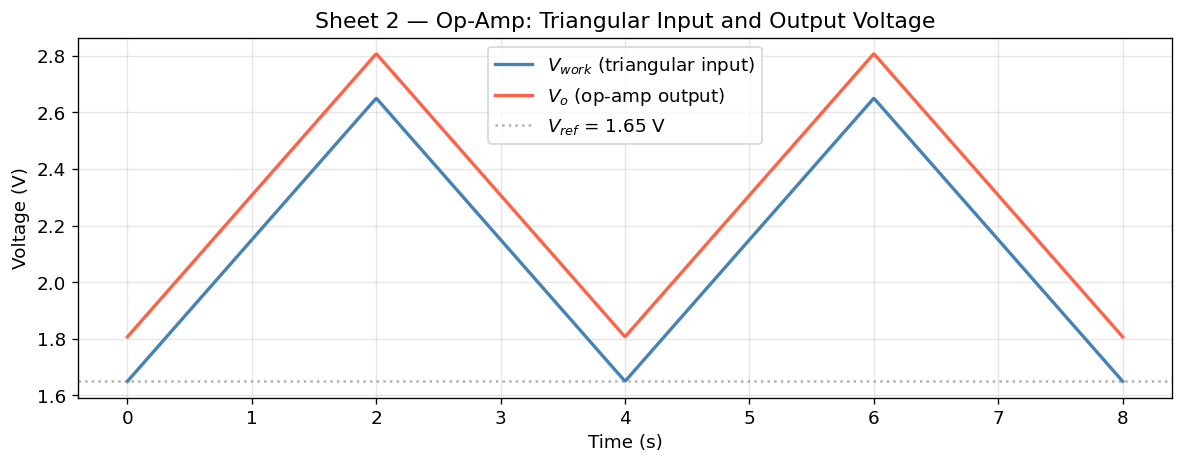

In [5]:
t_vals = np.linspace(0, 2 * T_op, 1000)
Vwork_vals = triangular_wave(t_vals, f_op, V_peak, V_ref)
Vo_vals    = Vo_func(t_vals)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_vals, Vwork_vals, 'steelblue',  linewidth=2, label='$V_{work}$ (triangular input)')
ax.plot(t_vals, Vo_vals,    'tomato',     linewidth=2, label='$V_o$ (op-amp output)')
ax.axhline(V_ref, color='gray', linestyle=':', alpha=0.6, label=f'$V_{{ref}}$ = {V_ref} V')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')
ax.set_title('Sheet 2 — Op-Amp: Triangular Input and Output Voltage')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Waveform Vx(t)
*(Sheet 2)*

Linear ramp: $V_x(t) = 2 f (V_{max} - V_{min}) \cdot t$

In [6]:
# ── Parameters ─────────────────────────────────────────────────────────────────
Vmax_vx = 1.0
Vmin_vx = -1.0
f_vx    = 0.25

t_vx = [0, 0.25, 0.5, 0.75, 1.0, 1.5]   # time samples (s)
Vx   = [2 * f_vx * (Vmax_vx - Vmin_vx) * t for t in t_vx]

print("Waveform Vx(t) = 2f(Vmax - Vmin) · t")
print("=" * 38)
print(f"  Vmax = {Vmax_vx} V,  Vmin = {Vmin_vx} V,  f = {f_vx} Hz")
print()
print(f"  {'t (s)':<10} {'Vx (V)'}")
print(f"  {'─'*22}")
for t, v in zip(t_vx, Vx):
    print(f"  {t:<10.2f} {v:.4f}")

Waveform Vx(t) = 2f(Vmax - Vmin) · t
  Vmax = 1.0 V,  Vmin = -1.0 V,  f = 0.25 Hz

  t (s)      Vx (V)
  ──────────────────────
  0.00       0.0000
  0.25       0.2500
  0.50       0.5000
  0.75       0.7500
  1.00       1.0000
  1.50       1.5000


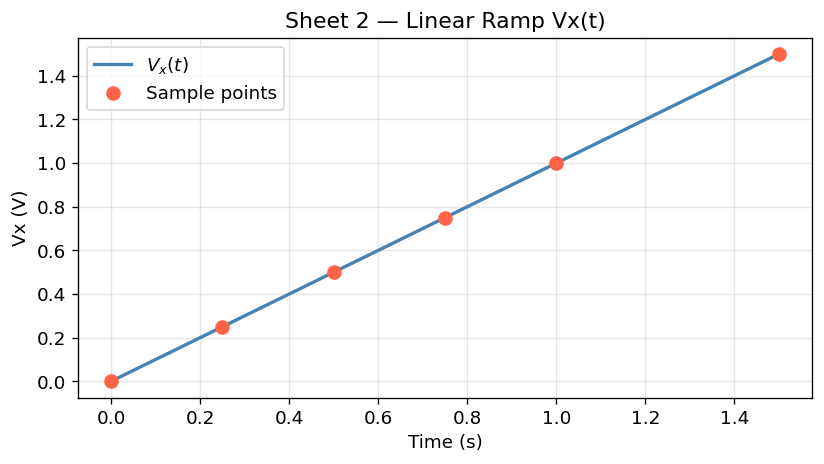

In [7]:
t_cont = np.linspace(0, 1.5, 300)
Vx_cont = 2 * f_vx * (Vmax_vx - Vmin_vx) * t_cont

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_cont, Vx_cont, 'steelblue', linewidth=2, label='$V_x(t)$')
ax.scatter(t_vx, Vx, color='tomato', zorder=5, s=60, label='Sample points')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Vx (V)')
ax.set_title('Sheet 2 — Linear Ramp Vx(t)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. CNT Supercapacitor Design
*(Sheet 3)*

Models a carbon-nanotube (CNT) based supercapacitor chip: geometry, capacitance, energy storage, material volumes, and thermal analysis.

In [8]:
# ── CNT Geometry ───────────────────────────────────────────────────────────────
r_cnt = 5e-9          # CNT radius (m)
h_cnt = 2.5e-4        # CNT length (m)  [0.25 mm]

# ── Nanostructure dimensions ───────────────────────────────────────────────────
x_ns  = 3e-6          # Width of nanostructure (m)
y_ns  = 0.0254        # Length of nanostructure (m)  [1 inch]
d_gap = 2e-6          # Gap between nanostructures (m)

# ── Dielectric properties ──────────────────────────────────────────────────────
eo    = 8.854e-12     # Permittivity of free space (F/m)
er    = 1000          # Relative permittivity
V_charge_max = 1000   # Max charging voltage (V)
V_op_cap     = 3      # Operating voltage (V)
I_charge     = 1      # Charging current (A)

# ── Chip dimensions ───────────────────────────────────────────────────────────
L_chip = 0.0254       # Chip length (m)  [1 inch]
W_chip = 0.0254       # Chip width  (m)  [1 inch]

# ── Layer thicknesses ──────────────────────────────────────────────────────────
t_Si        = 3e-4    # Silicon substrate (m)
t_M1        = 1e-7    # Metal 1 — Titanium layer (m)
t_SiO2_lyr  = 1e-6   # SiO₂ single layer (m)
t_SiO2      = t_M1 + 2 * t_SiO2_lyr          # Total SiO₂ thickness (m)
t_M2        = 1e-8    # Metal 2 — Aluminum layer (m)
t_catalyst  = 1e-8    # Catalyst — Iron layer (m)
t_CNT_layer = h_cnt   # CNT layer thickness = CNT length
t_dielectric_lyr = 2e-6    # Dielectric single layer (m)
t_dielectric = t_CNT_layer + t_dielectric_lyr  # Total dielectric (m)
t_total     = t_Si + t_SiO2 + t_M2 + t_catalyst + t_dielectric

print("CNT Supercapacitor — Input Parameters")
print("=" * 42)
print(f"  CNT radius          r  = {r_cnt*1e9:.1f} nm")
print(f"  CNT length          h  = {h_cnt*1e6:.0f} µm")
print(f"  NS width            x  = {x_ns*1e6:.0f} µm")
print(f"  NS length           y  = {y_ns*100:.2f} cm")
print(f"  Gap                 d  = {d_gap*1e6:.0f} µm")
print(f"  Relative permittivity  = {er}")
print(f"  Max charge voltage     = {V_charge_max} V")
print(f"  Total stack thickness  = {t_total*1e6:.2f} µm")

CNT Supercapacitor — Input Parameters
  CNT radius          r  = 5.0 nm
  CNT length          h  = 250 µm
  NS width            x  = 3 µm
  NS length           y  = 2.54 cm
  Gap                 d  = 2 µm
  Relative permittivity  = 1000
  Max charge voltage     = 1000 V
  Total stack thickness  = 554.12 µm


In [9]:
# ── Geometry calculations ──────────────────────────────────────────────────────
SA_cnt          = np.pi*r_cnt**2 + 2*np.pi*r_cnt*h_cnt      # CNT surface area (m²)
A_ns_base       = x_ns * y_ns                                 # NS base area (m²)
N_cnt_per_ns    = A_ns_base / (np.pi * r_cnt**2)             # CNTs per NS
A_total_ns      = N_cnt_per_ns * SA_cnt                       # Total CNT surface area per NS (m²)

A_chip          = L_chip * W_chip                             # Chip area (m²)
N_pairs         = (W_chip - x_ns) / (x_ns + d_gap)           # Number of NS pairs on chip

print("CNT Supercapacitor — Geometry")
print("=" * 42)
print(f"  SA per CNT          = {SA_cnt:.4e} m²")
print(f"  NS base area        = {A_ns_base:.4e} m²")
print(f"  CNTs per NS         = {N_cnt_per_ns:.2e}")
print(f"  Total CNT SA per NS = {A_total_ns:.4e} m²")
print(f"  Chip area           = {A_chip*100:.4f} cm²")
print(f"  Number of NS pairs  = {N_pairs:.0f}")

CNT Supercapacitor — Geometry
  SA per CNT          = 7.8541e-12 m²
  NS base area        = 7.6200e-08 m²
  CNTs per NS         = 9.70e+08
  Total CNT SA per NS = 7.6201e-03 m²
  Chip area           = 0.0645 cm²
  Number of NS pairs  = 5079


In [10]:
# ── Capacitance and energy ─────────────────────────────────────────────────────
C_pair   = (eo * er * A_total_ns) / d_gap           # Capacitance of 1 NS pair (F)
C_chip   = C_pair * N_pairs                          # Total chip capacitance (F)

E_pair   = 0.5 * C_pair * V_charge_max**2            # Energy per pair (J)
E_chip   = E_pair * N_pairs                          # Total chip energy (J)

Wh_chip  = E_chip / 54000                            # Wh (per original formula)
mAh_chip = (Wh_chip * 1000) / V_op_cap              # mAh

Vol_chip_m3  = ((2*x_ns + d_gap) * y_ns * t_total) * N_pairs  # m³
Vol_chip_L   = Vol_chip_m3 * 1000                              # Litres

Wh_per_L  = Wh_chip  / Vol_chip_L
mAh_per_L = mAh_chip / Vol_chip_L

t_charge_s = C_pair * V_charge_max / I_charge         # Time to charge 1 pair (s)

print("CNT Supercapacitor — Capacitance & Energy")
print("=" * 46)
print(f"  Capacitance per pair = {C_pair:.4e} F")
print(f"  Chip capacitance     = {C_chip:.4e} F")
print(f"  Energy per pair      = {E_pair:.4e} J")
print(f"  Total chip energy    = {E_chip:.4e} J")
print(f"  Energy (Wh)          = {Wh_chip:.4e} Wh")
print(f"  Energy (mAh)         = {mAh_chip:.4e} mAh")
print(f"  Chip volume          = {Vol_chip_L:.4e} L")
print(f"  Wh/L                 = {Wh_per_L:.4e}")
print(f"  mAh/L                = {mAh_per_L:.4e}")
print(f"  Charge time          = {t_charge_s:.4e} s  ({t_charge_s/60:.2f} min)")

CNT Supercapacitor — Capacitance & Energy
  Capacitance per pair = 3.3734e-05 F
  Chip capacitance     = 1.7135e-01 F
  Energy per pair      = 1.6867e+01 J
  Total chip energy    = 8.5674e+04 J
  Energy (Wh)          = 1.5866e+00 Wh
  Energy (mAh)         = 5.2885e+02 mAh
  Chip volume          = 5.7193e-04 L
  Wh/L                 = 2.7741e+03
  mAh/L                = 9.2469e+05
  Charge time          = 3.3734e-02 s  (0.00 min)


In [11]:
# ── Material volumes (per NS pair) ─────────────────────────────────────────────
Vol_Si   = (2*x_ns + d_gap) * y_ns * t_Si
Vol_SiO2 = 4*x_ns*y_ns*t_SiO2_lyr + (d_gap*y_ns*(2*t_SiO2_lyr + t_M1))
Vol_M1   = 2 * x_ns * y_ns * t_M1
Vol_M2   = 2 * x_ns * y_ns * t_M2
Vol_cat  = 2 * x_ns * y_ns * t_catalyst
Vol_CNT  = 2 * x_ns * y_ns * h_cnt
Vol_diel = (2*x_ns + d_gap)*y_ns*t_dielectric_lyr + d_gap*y_ns*(t_M2 + t_catalyst + h_cnt)
Vol_pair = (2*x_ns + d_gap) * y_ns * t_total

layers = {
    'Silicon': Vol_Si,
    'SiO₂':   Vol_SiO2,
    'Metal 1\n(Ti)': Vol_M1,
    'Metal 2\n(Al)': Vol_M2,
    'Catalyst\n(Fe)': Vol_cat,
    'CNT':    Vol_CNT,
    'Dielectric': Vol_diel,
}

print("CNT Supercapacitor — Material Volumes (per NS pair)")
print("=" * 52)
for name, vol in layers.items():
    label = name.replace('\n', ' ')
    print(f"  {label:<18} {vol:.4e} m³")
print(f"  {'Total pair':<18} {Vol_pair:.4e} m³")

CNT Supercapacitor — Material Volumes (per NS pair)
  Silicon            6.0960e-11 m³
  SiO₂               4.1148e-13 m³
  Metal 1 (Ti)       1.5240e-14 m³
  Metal 2 (Al)       1.5240e-15 m³
  Catalyst (Fe)      1.5240e-15 m³
  CNT                3.8100e-11 m³
  Dielectric         1.3107e-11 m³
  Total pair         1.1260e-10 m³


In [12]:
# ── Thermal analysis ───────────────────────────────────────────────────────────
# (Resistivity Ω·m, Density kg/m³, Volume m³, Specific Heat J/kg·K)
materials_thermal = {
    'Aluminum': dict(rho=2.82e-8, density=2600, vol=Vol_M2,  Cp=921),
    'Titanium': dict(rho=4.2e-5,  density=4510, vol=Vol_M1,  Cp=1262),
    'Iron (Fe)': dict(rho=1e-7,   density=7870, vol=Vol_cat, Cp=554),
    'Carbon CNTs': dict(rho=5e-6, density=3510, vol=Vol_CNT, Cp=521),
}

print("Thermal Analysis")
print("=" * 80)
print(f"  {'Material':<14} {'Mass (g)':<12} {'R (Ω)':<14} {'Power (W)':<12} {'Q (J)':<12} {'ΔT (K)'}")
print(f"  {'─'*74}")

for name, m in materials_thermal.items():
    mass     = m['density'] * m['vol']                      # kg
    R_elec   = (m['rho'] * y_ns) / (x_ns * m['vol'] / (y_ns * x_ns * 2))  # rough
    # Original formula: R = (rho * y_ns) / (x_ns * thickness)
    # thickness from volume: vol = 2*x_ns*y_ns*thickness → thickness = vol/(2*x_ns*y_ns)
    thickness = m['vol'] / (2 * x_ns * y_ns)
    R_elec   = (m['rho'] * y_ns) / (x_ns * thickness)
    P        = R_elec * I_charge**2
    Q        = P * t_charge_s
    delta_T  = Q / (mass * m['Cp']) if mass > 0 else float('inf')
    print(f"  {name:<14} {mass*1000:<12.4e} {R_elec:<14.4e} {P:<12.4e} {Q:<12.4e} {delta_T:.4e}")

Thermal Analysis
  Material       Mass (g)     R (Ω)          Power (W)    Q (J)        ΔT (K)
  ──────────────────────────────────────────────────────────────────────────
  Aluminum       3.9624e-09   2.3876e+04     2.3876e+04   8.0543e+02   2.2071e+11
  Titanium       6.8732e-08   3.5560e+06     3.5560e+06   1.1996e+05   1.3830e+12
  Iron (Fe)      1.1994e-08   8.4667e+04     8.4667e+04   2.8562e+03   4.2984e+11
  Carbon CNTs    1.3373e-04   1.6933e+02     1.6933e+02   5.7123e+00   8.1986e+04


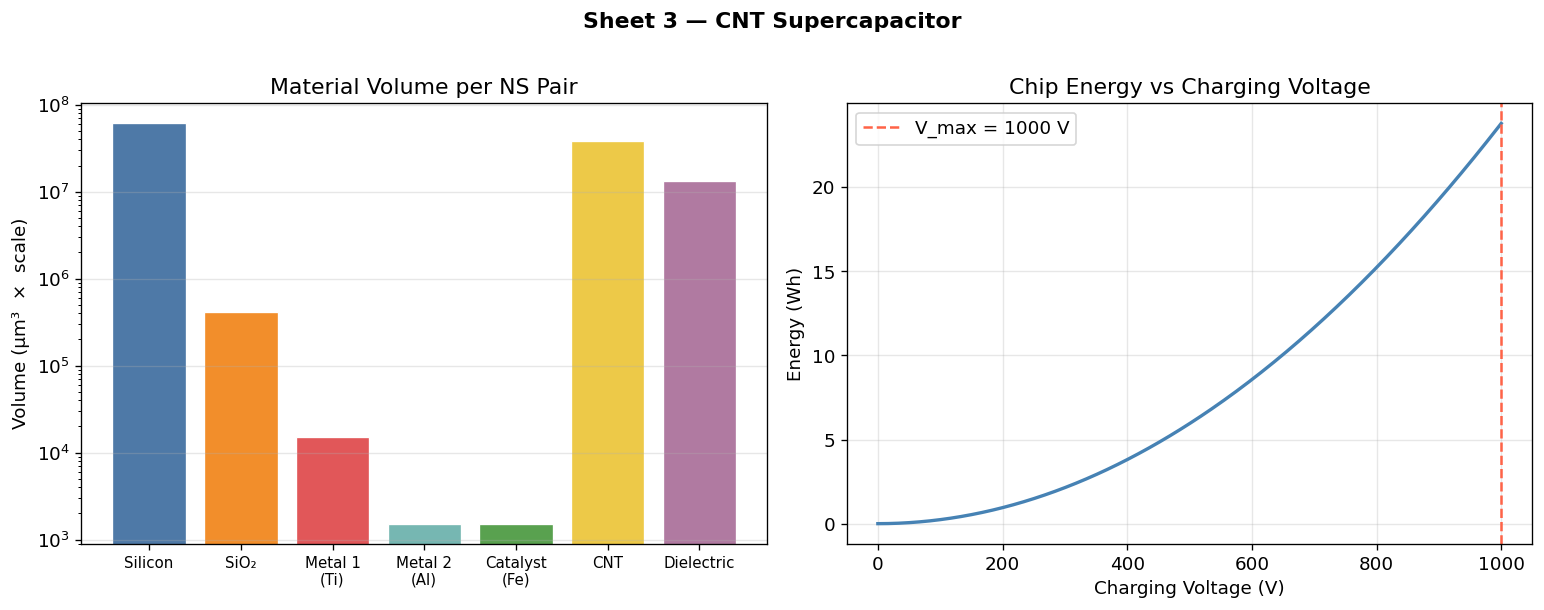

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Volume breakdown
labels = list(layers.keys())
vols   = [v * 1e18 for v in layers.values()]   # convert to µm³ for readability
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948','#b07aa1']
bars = axes[0].bar(range(len(labels)), vols, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel('Volume (µm³  ×  scale)')
axes[0].set_title('Material Volume per NS Pair')
axes[0].set_yscale('log')
axes[0].grid(True, axis='y', alpha=0.3)

# Energy vs charging voltage
V_sweep = np.linspace(0, 1000, 300)
E_sweep = 0.5 * C_chip * V_sweep**2
Wh_sweep = E_sweep / 3600
axes[1].plot(V_sweep, Wh_sweep, 'steelblue', linewidth=2)
axes[1].axvline(V_charge_max, color='tomato', linestyle='--',
                label=f'V_max = {V_charge_max} V')
axes[1].set_xlabel('Charging Voltage (V)')
axes[1].set_ylabel('Energy (Wh)')
axes[1].set_title('Chip Energy vs Charging Voltage')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sheet 3 — CNT Supercapacitor', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. COVID DNA Biosensor — CEDL Model
*(COVID DNA Detection Cap sheet)*

Computes the **Electrochemical Double Layer Capacitance (CEDL)** for a CNT-based DNA biosensor at 1 fM ion concentration, using Gouy-Chapman-Stern theory:

$$C_{EDL}/A = \sqrt{\frac{2z^2e^2N_AC_0\varepsilon_r\varepsilon_0}{kT}} \cdot \cosh\!\left(\frac{ze\zeta}{2kT}\right)$$

In [14]:
# ── Parameters ─────────────────────────────────────────────────────────────────
C_ion_fM = 1e-15     # Ion concentration (M)  [1 fM]
z_val    = 1         # Ionic valence
e_charge = 1.6e-19   # Elementary charge (C)
Co_fM    = C_ion_fM * 1000   # Molar conc in mol/m³
er_w     = 78.49     # Relative permittivity of water
eo       = 8.854e-12 # Permittivity of free space (F/m)
k_B      = 1.38e-23  # Boltzmann constant (J/K)
T_K      = 298.1     # Temperature (K)
V_zeta   = 0.05      # Zeta potential (V)
Na       = 6.022e23  # Avogadro's number

# CNT geometry
r_bs  = 5e-9         # CNT radius (m)
h_bs  = 1e-4         # CNT height (m)  [0.1 mm]
SA_bs = np.pi*r_bs**2 + 2*np.pi*r_bs*h_bs  # SA per CNT (m²)

# Chip / sensor dimensions
L_sens = 1e-5        # Length (m)  [10 µm]
W_sens = 1e-5        # Width  (m)  [10 µm]

# ── CEDL calculation ───────────────────────────────────────────────────────────
sqrt_term = np.sqrt((2 * z_val**2 * e_charge**2 * Na * Co_fM * er_w * eo)
                    / (k_B * T_K))
cosh_term = np.cosh((z_val * e_charge * V_zeta) / (2 * k_B * T_K))
C_EDL_per_area = sqrt_term * cosh_term     # F/m²

# Debye screening length
d_EDL = np.sqrt((k_B * T_K * eo * er_w)
                / (2 * z_val**2 * e_charge**2 * Na * Co_fM))   # m

# C_EDL per area from Debye length
C_EDL_debye = (eo * er_w) / d_EDL    # F/m²

# Per CNT and per sensor
CEDL_1CNT  = C_EDL_per_area * SA_bs
N_cnt_sens = (L_sens * W_sens) / (np.pi * (2 * r_bs)**2)
CEDL_1NS   = CEDL_1CNT * N_cnt_sens

print("COVID DNA Biosensor — CEDL Model (1 fM)")
print("=" * 48)
print(f"  Ion concentration         = {C_ion_fM:.0e} M  (1 fM)")
print(f"  Co (mol/m³)               = {Co_fM:.4e}")
print(f"  √ term                    = {sqrt_term:.4e}")
print(f"  cosh term                 = {cosh_term:.4f}")
print(f"  CEDL/A (GCS)              = {C_EDL_per_area:.4e} F/m²")
print(f"  Debye length d_EDL        = {d_EDL:.4e} m  ({d_EDL*1e9:.2f} nm)")
print(f"  CEDL/A (Debye)            = {C_EDL_debye:.4e} F/m²")
print(f"  SA per CNT                = {SA_bs:.4e} m²")
print(f"  CEDL per CNT              = {CEDL_1CNT:.4e} F")
print(f"  No. of CNTs on sensor     = {N_cnt_sens:.2e}")
print(f"  CEDL per nanostructure    = {CEDL_1NS:.4e} F")

COVID DNA Biosensor — CEDL Model (1 fM)
  Ion concentration         = 1e-15 M  (1 fM)
  Co (mol/m³)               = 1.0000e-12
  √ term                    = 7.2171e-08
  cosh term                 = 1.5112
  CEDL/A (GCS)              = 1.0906e-07 F/m²
  Debye length d_EDL        = 9.6292e-03 m  (9629241.93 nm)
  CEDL/A (Debye)            = 7.2171e-08 F/m²
  SA per CNT                = 3.1417e-12 m²
  CEDL per CNT              = 3.4264e-19 F
  No. of CNTs on sensor     = 3.18e+05
  CEDL per nanostructure    = 1.0906e-13 F


---
## 6. COVID DNA Biosensor — Full Model
*(COVID Detection Clean Sheet)*

Full biosensor model including:
- **CEDL** (double-layer capacitance)
- **C_H** (DNA hybridization capacitance, ssDNA probe layer)
- **C_H1** (post-hybridization, double-stranded DNA)
- Series combination → total impedance and detection current
- Delta quantities: ΔI, ΔZ, ΔC on hybridization

In [15]:
# ── Parameters ─────────────────────────────────────────────────────────────────
C_ion_full = 10       # Ion concentration (M)  [10 M]
Co_full    = C_ion_full * 1000     # mol/m³
# (z, e, er_w, eo, k_B, T_K, V_zeta, Na same as Section 5)

f_sense  = 1e5        # Sensing frequency (Hz)  [100 kHz]
R_sense  = 1e5        # Series resistance (Ω)   [100 kΩ]

# CNT geometry (same as Section 5, but restate for clarity)
r_f  = 5e-9           # CNT radius (m)
h_f  = 1e-4           # CNT height (m)
SA_f = np.pi*r_f**2 + 2*np.pi*r_f*h_f

L_f  = 1e-5           # Sensor length (m)
W_f  = 1e-5           # Sensor width (m)
N_cnt_f = (L_f * W_f) / (np.pi * (2*r_f)**2)   # No. of CNTs
SA_ns_f = N_cnt_f * SA_f                         # SA of full NS

# DNA / functional molecule parameters
er_DNA   = 8          # Relative permittivity of ssDNA
L_DNA    = 2e-9       # DNA probe length (m)  [20 nucleotides ≈ 2 nm]
R_mol    = 5e-10      # Radius of functional molecule (m)  [1 nm diameter]
gap_mol  = 5e-10      # Gap between molecules (m)

# ── CEDL at 10 M ──────────────────────────────────────────────────────────────
sqrt_f   = np.sqrt((2 * z_val**2 * e_charge**2 * Na * Co_full * er_w * eo)
                   / (k_B * T_K))
cosh_f   = np.cosh((z_val * e_charge * V_zeta) / (2 * k_B * T_K))
C_EDL_A_full = sqrt_f * cosh_f     # F/m²

d_EDL_full  = np.sqrt((k_B * T_K * eo * er_w)
                       / (2 * z_val**2 * e_charge**2 * Na * Co_full))  # m
C_EDL_full  = (eo * er_w) / d_EDL_full     # F/m²

CEDL_1CNT_f = C_EDL_A_full * SA_f
CEDL_NS_f   = CEDL_1CNT_f * N_cnt_f

# ── DNA probe layer capacitance (C_H) ─────────────────────────────────────────
C_H_area    = (er_DNA * eo) / L_DNA        # F/m²
C_H_1CNT    = C_H_area * SA_f
C_H_NS      = C_H_1CNT * N_cnt_f           # Total C_H for sensor NS

# Number of functional molecules
N_mol_1CNT  = SA_f / (np.pi * (R_mol + gap_mol)**2)
N_mol_NS    = N_mol_1CNT * N_cnt_f
conc_mol_m3 = N_mol_NS / Na                # mol/m³
conc_mol_M  = conc_mol_m3 / 1000           # M

# ── Series combination: 1/C_total = 1/C_H + 1/CEDL ───────────────────────────
C_probe_inv = 1/C_H_NS + 1/CEDL_NS_f
C_probe     = 1 / C_probe_inv              # Probe-only total capacitance (F)

Z_probe  = 1 / (2 * pi * f_sense * C_probe)           # Impedance (Ω)
Z_RC_probe = np.sqrt(R_sense**2 + Z_probe**2)          # With series R
i_probe  = V_zeta / Z_probe                            # Without R
i_probe_R = V_zeta / Z_RC_probe                        # With R

print("COVID Biosensor — Probe-Only (ssDNA, 10 M)")
print("=" * 50)
print(f"  CEDL/A                = {C_EDL_A_full:.4e} F/m²")
print(f"  Debye length          = {d_EDL_full*1e12:.4f} pm")
print(f"  CEDL per NS           = {CEDL_NS_f:.4e} F")
print(f"  C_H per unit area     = {C_H_area:.4e} F/m²")
print(f"  C_H per NS            = {C_H_NS:.4e} F")
print(f"  No. molecules per NS  = {N_mol_NS:.2e}")
print(f"  Mol. conc. on NS      = {conc_mol_M:.4e} M")
print(f"  C total (probe)       = {C_probe:.4e} F")
print(f"  Z impedance (probe)   = {Z_probe:.4e} Ω")
print(f"  Z with R (probe)      = {Z_RC_probe:.4e} Ω")
print(f"  Current i (probe)     = {i_probe:.4e} A")

COVID Biosensor — Probe-Only (ssDNA, 10 M)
  CEDL/A                = 1.0906e+01 F/m²
  Debye length          = 96.2924 pm
  CEDL per NS           = 1.0906e-05 F
  C_H per unit area     = 3.5416e-02 F/m²
  C_H per NS            = 3.5417e-08 F
  No. molecules per NS  = 3.18e+11
  Mol. conc. on NS      = 5.2859e-16 M
  C total (probe)       = 3.5302e-08 F
  Z impedance (probe)   = 4.5065e+01 Ω
  Z with R (probe)      = 1.0000e+05 Ω
  Current i (probe)     = 1.1095e-03 A


In [16]:
# ── Post-hybridization (dsDNA, C_H1) ──────────────────────────────────────────
er_DNA_h  = 8          # Permittivity after hybridization
L_DNA_h   = 2e-9       # dsDNA effective length (m)
f_hybrid  = 1e4        # Sensing frequency after hybridization (Hz)  [10 kHz]

C_H1_area = (er_DNA_h * eo) / L_DNA_h     # Same formula, could differ with dsDNA
C_H1_1CNT = C_H1_area * SA_f
C_H1_NS   = C_H1_1CNT * N_cnt_f

# Alternative formula from Excel: CH1 = [(er*eo)/(L1+L2)] * SA_1CNT * N_CNTs
C_H1_combined = ((er_DNA * eo) / (L_DNA + L_DNA_h)) * SA_f * N_cnt_f

# Series: 1/C_hybrid = 1/C_H + 1/C_H1 + 1/CEDL
C_hybrid_inv = 1/C_H_NS + 1/C_H1_NS + 1/CEDL_NS_f
C_hybrid     = 1 / C_hybrid_inv

Z_hybrid    = 1 / (2 * pi * f_hybrid * C_hybrid)     # Ω
Z_CEDL_NS_f = 1 / (2 * pi * f_sense * CEDL_NS_f)     # CEDL alone
i_hybrid    = V_zeta / Z_hybrid

# ── Delta values (change on hybridization) ─────────────────────────────────────
delta_I = i_probe_R - i_hybrid      # Current change (A)
delta_Z = Z_probe   - Z_hybrid      # Impedance change (Ω)
delta_C = C_probe   - C_hybrid      # Capacitance change (F)

print("COVID Biosensor — Post-Hybridization (dsDNA)")
print("=" * 50)
print(f"  C_H1 per NS           = {C_H1_NS:.4e} F")
print(f"  C combined (CH+CH1)   = {C_H1_combined:.4e} F")
print(f"  C total (hybrid)      = {C_hybrid:.4e} F")
print(f"  Z impedance (hybrid)  = {Z_hybrid:.4e} Ω  @ {f_hybrid/1e3:.0f} kHz")
print(f"  Current i (hybrid)    = {i_hybrid:.4e} A")
print()
print("  Detection Signal")
print(f"  ΔI (current change)   = {delta_I:.4e} A")
print(f"  ΔZ (impedance change) = {delta_Z:.4e} Ω")
print(f"  ΔC (capacitance chg)  = {delta_C:.4e} F")

COVID Biosensor — Post-Hybridization (dsDNA)


  C_H1 per NS           = 3.5417e-08 F
  C combined (CH+CH1)   = 1.7708e-08 F
  C total (hybrid)      = 1.7680e-08 F
  Z impedance (hybrid)  = 8.9985e+02 Ω  @ 10 kHz
  Current i (hybrid)    = 5.5565e-05 A

  Detection Signal
  ΔI (current change)   = -5.5065e-05 A
  ΔZ (impedance change) = -8.5478e+02 Ω
  ΔC (capacitance chg)  = 1.7623e-08 F


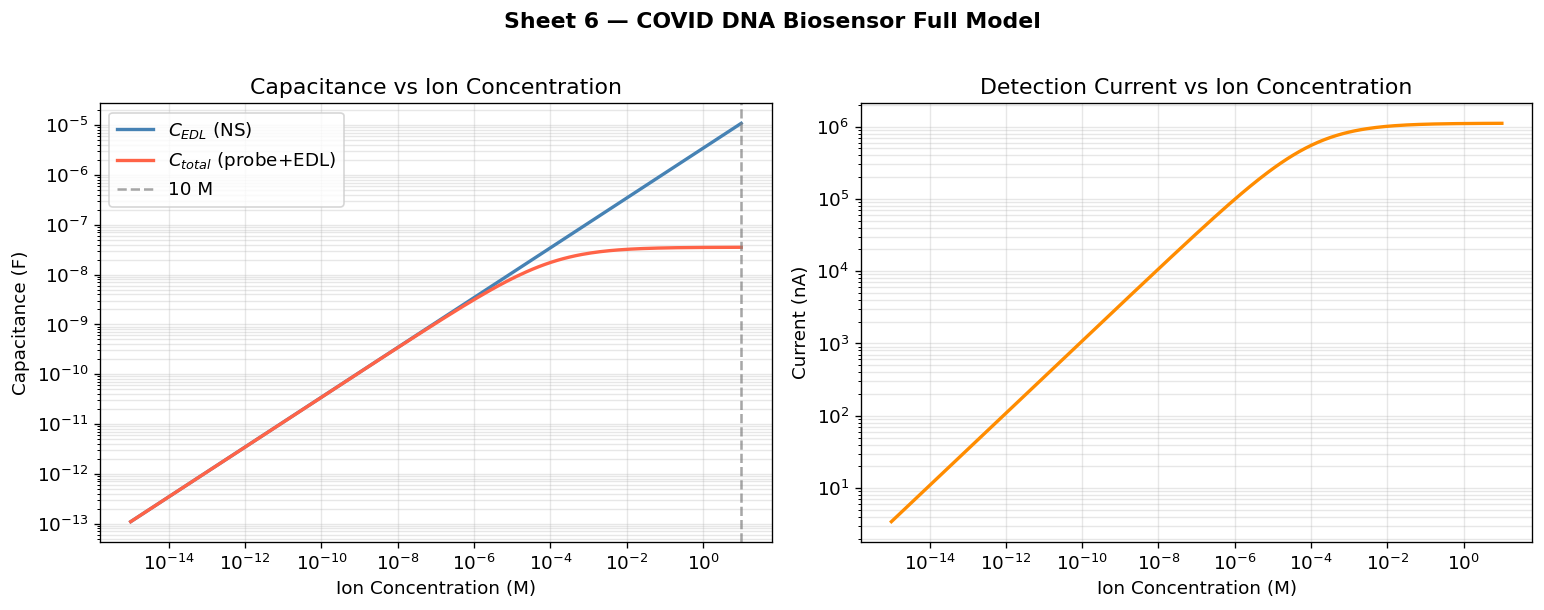

In [17]:
# ── CEDL and C_total vs ion concentration ─────────────────────────────────────
conc_sweep = np.logspace(-15, 1, 200)   # 1 fM → 10 M
Co_sweep   = conc_sweep * 1000

sqrt_s = np.sqrt((2 * z_val**2 * e_charge**2 * Na * Co_sweep * er_w * eo)
                 / (k_B * T_K))
CEDL_sweep  = sqrt_s * cosh_f * SA_f * N_cnt_f   # CEDL of NS
C_tot_sweep = 1 / (1/C_H_NS + 1/CEDL_sweep)      # series with C_H

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].loglog(conc_sweep, CEDL_sweep,  'steelblue', linewidth=2, label='$C_{EDL}$ (NS)')
axes[0].loglog(conc_sweep, C_tot_sweep, 'tomato',    linewidth=2, label='$C_{total}$ (probe+EDL)')
axes[0].axvline(C_ion_full, color='gray', linestyle='--', alpha=0.7, label='10 M')
axes[0].set_xlabel('Ion Concentration (M)')
axes[0].set_ylabel('Capacitance (F)')
axes[0].set_title('Capacitance vs Ion Concentration')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

Z_tot_sweep = 1 / (2 * pi * f_sense * C_tot_sweep)
i_tot_sweep = V_zeta / Z_tot_sweep
axes[1].loglog(conc_sweep, i_tot_sweep * 1e9, 'darkorange', linewidth=2)
axes[1].set_xlabel('Ion Concentration (M)')
axes[1].set_ylabel('Current (nA)')
axes[1].set_title('Detection Current vs Ion Concentration')
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('Sheet 6 — COVID DNA Biosensor Full Model', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Detection Curve
*(Detection Curve sheet)*

Sensor response (ΔC) as a function of ion/analyte concentration, showing Langmuir-type saturation at higher concentrations.

In [18]:
# ── Data from Excel ────────────────────────────────────────────────────────────
conc_func_groups = 5.25e-16   # Concentration of functional groups (M)

ion_conc = np.array([1e-15, 1e-12, 1e-9, 1e-6, 1e-3, 0.1, 1, 10])   # M
delta_C  = np.array([3.3e-16, 3.3e-16, 3.3e-13, 2.56e-10,
                     1.15e-8, 1.68e-8, 1.74e-8, 1.76e-8])             # F

print("Detection Curve Data")
print("=" * 42)
print(f"  Functional group conc = {conc_func_groups:.2e} M")
print()
print(f"  {'Ion Conc. (M)':<18} {'ΔC (F)'}")
print(f"  {'─'*32}")
for c, dc in zip(ion_conc, delta_C):
    print(f"  {c:<18.2e} {dc:.2e}")

Detection Curve Data
  Functional group conc = 5.25e-16 M

  Ion Conc. (M)      ΔC (F)
  ────────────────────────────────
  1.00e-15           3.30e-16
  1.00e-12           3.30e-16
  1.00e-09           3.30e-13
  1.00e-06           2.56e-10
  1.00e-03           1.15e-08
  1.00e-01           1.68e-08
  1.00e+00           1.74e-08
  1.00e+01           1.76e-08


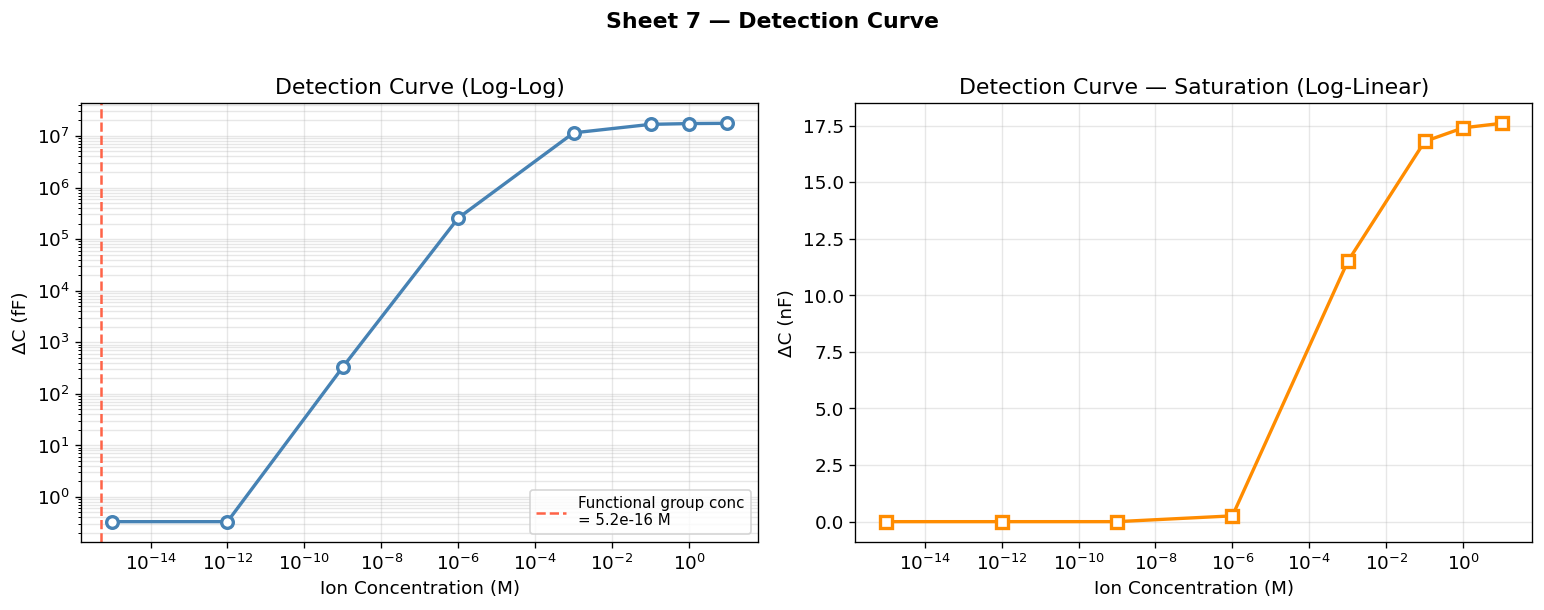

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Log-log
axes[0].loglog(ion_conc, delta_C * 1e15, 'o-', color='steelblue',
               linewidth=2, markersize=7, markerfacecolor='white',
               markeredgewidth=2)
axes[0].axvline(conc_func_groups, color='tomato', linestyle='--',
                label=f'Functional group conc\n= {conc_func_groups:.1e} M')
axes[0].set_xlabel('Ion Concentration (M)')
axes[0].set_ylabel('ΔC (fF)')
axes[0].set_title('Detection Curve (Log-Log)')
axes[0].legend(fontsize=9)
axes[0].grid(True, which='both', alpha=0.3)

# Log-linear to show saturation
axes[1].semilogx(ion_conc, delta_C * 1e9, 's-', color='darkorange',
                 linewidth=2, markersize=7, markerfacecolor='white',
                 markeredgewidth=2)
axes[1].set_xlabel('Ion Concentration (M)')
axes[1].set_ylabel('ΔC (nF)')
axes[1].set_title('Detection Curve — Saturation (Log-Linear)')
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('Sheet 7 — Detection Curve', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()